# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [3]:
train = pd.read_csv('iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Pada dataset Titanic kita melihat perbandingan distribusi spesies berdasarkan jenis kelamin Pria dan Wanita, pada dataset Iris tidak memiliki kolom jenis kelamin, melainkan data ini berisi pengukuran dimensi fisik bunga. Visualisasi yang paling mendekati dan berguna untuk dataset Iris adalah melihat perbandingan antar spesies.

<Axes: xlabel='Species', ylabel='count'>

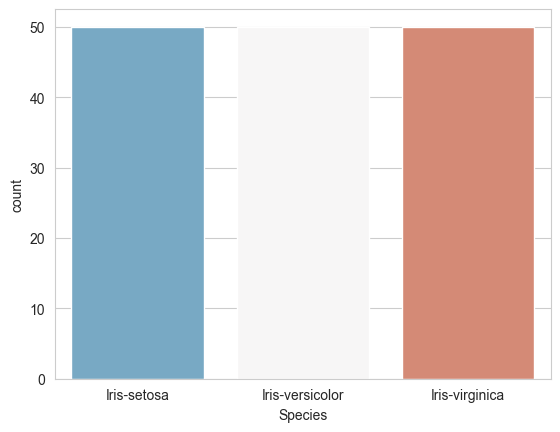

In [6]:
# Cek jumlah data untuk setiap spesies
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, hue='Species', palette='RdBu_r', legend=False)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

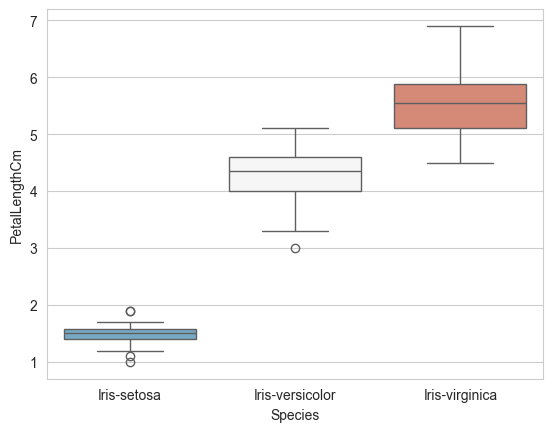

In [7]:
sns.boxplot(x='Species', y='PetalLengthCm', data=train, hue='Species', palette='RdBu_r', legend=False)

<Axes: xlabel='Species', ylabel='count'>

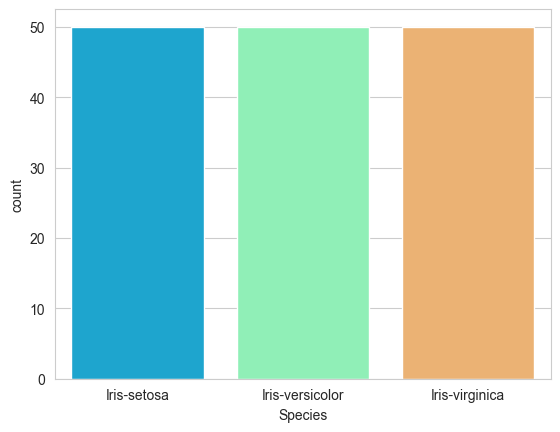

In [8]:
# cek distribusi jumlah data untuk setiap spesies
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, hue='Species', palette='rainbow', legend=False)

                 PetalLengthCm
Species                       
Iris-setosa              1.464
Iris-versicolor          4.260
Iris-virginica           5.552


(array([0, 1, 2]),
 [Text(0, 0, 'Iris-setosa'),
  Text(1, 0, 'Iris-versicolor'),
  Text(2, 0, 'Iris-virginica')])

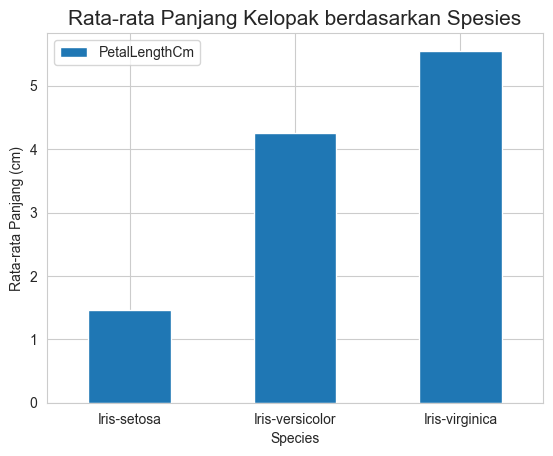

In [9]:
# Menghitung rata-rata panjang kelopak per spesies
avg_petal_length = train.groupby('Species')['PetalLengthCm'].mean()
avg_petal_length = pd.DataFrame(avg_petal_length)

# Menampilkan hasil dataframe grouping
print(avg_petal_length)

# Plotting
avg_petal_length.plot.bar()
plt.title("Rata-rata Panjang Kelopak berdasarkan Spesies", fontsize=15)
plt.ylabel("Rata-rata Panjang (cm)")
plt.xticks(rotation=0) # Agar nama spesies tidak miring

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5044\3408736198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

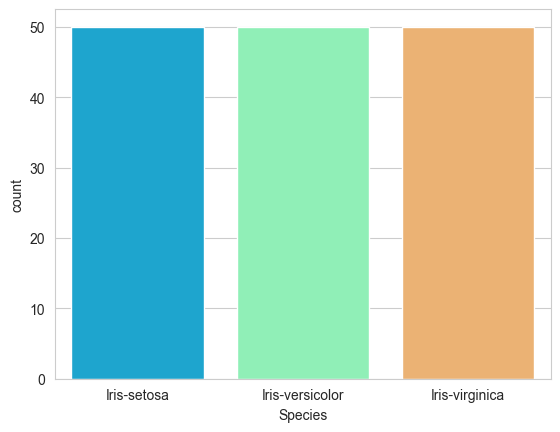

In [11]:
# Visualisasi hubungan
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='rainbow')

Text(0.5, 1.0, 'Histogram Panjang Sepal')

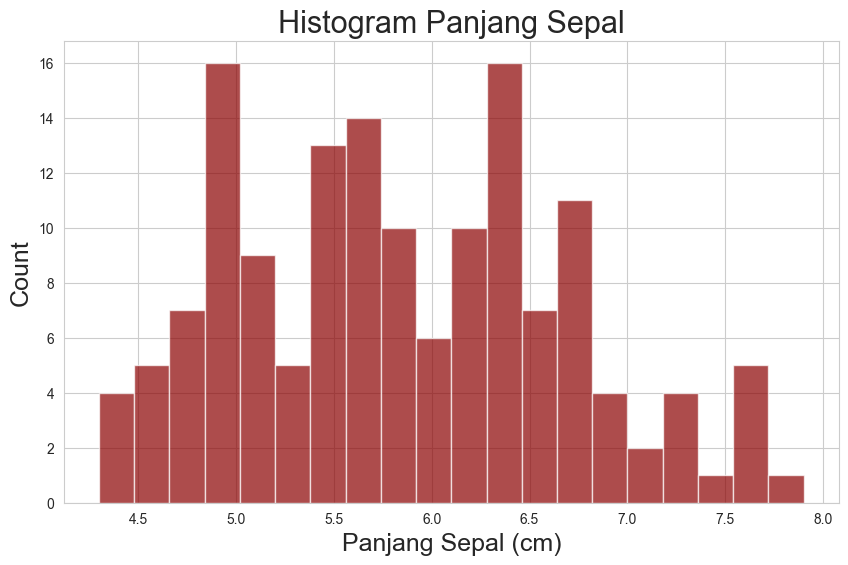

In [12]:
# Cek distribusi dari Panjang Sepal
plt.figure(figsize=(10,6))
train['SepalLengthCm'].hist(bins=20, color='darkred', alpha=0.7)

plt.xlabel("Panjang Sepal (cm)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Panjang Sepal", fontsize=22)

Text(0.5, 1.0, 'Distribusi Panjang Sepal berdasarkan Spesies')

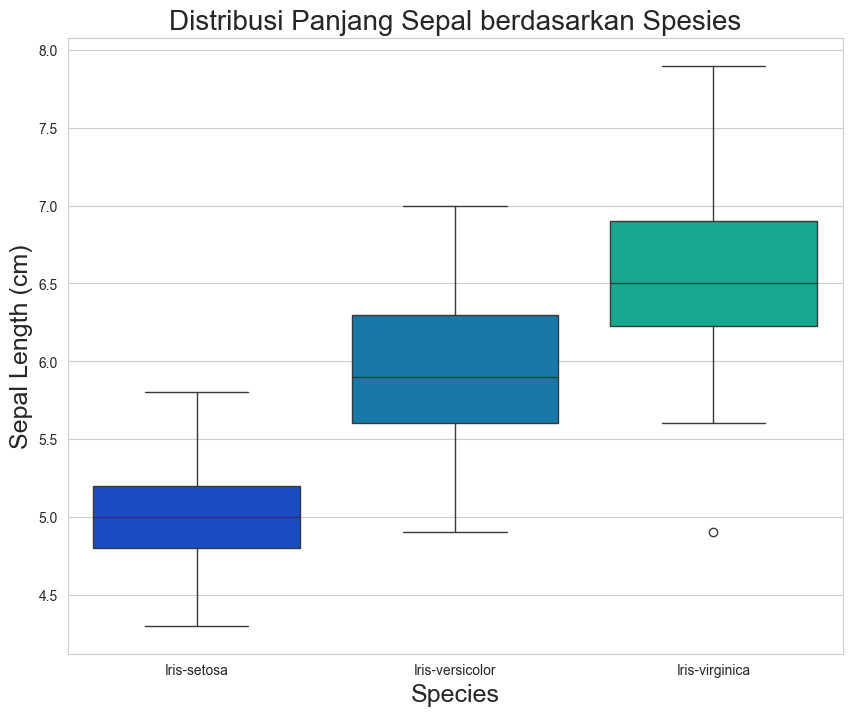

In [13]:
# Distribusi Panjang Sepal di setiap Spesies
plt.figure(figsize=(10, 8))

# Menggunakan Species sebagai sumbu x dan SepalLengthCm sebagai sumbu y
sns.boxplot(x='Species', y='SepalLengthCm', data=train, hue='Species', palette='winter', legend=False)

plt.xlabel("Species", fontsize=18)
plt.ylabel("Sepal Length (cm)", fontsize=18)
plt.title("Distribusi Panjang Sepal berdasarkan Spesies", fontsize=20)

(array([0, 1, 2]),
 [Text(0, 0, 'Iris-setosa'),
  Text(1, 0, 'Iris-versicolor'),
  Text(2, 0, 'Iris-virginica')])

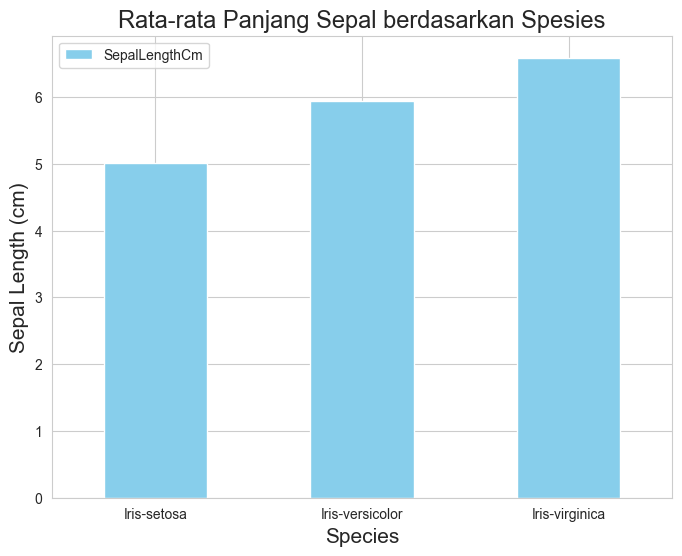

In [14]:
# Menghitung rata-rata Panjang Sepal berdasarkan Spesies
f_species_Sepal = train.groupby('Species')['SepalLengthCm'].mean()
f_species_Sepal = pd.DataFrame(f_species_Sepal)

# Membuat Bar Plot
f_species_Sepal.plot.bar(y='SepalLengthCm', color='skyblue', figsize=(8,6))

# Menyesuaikan Judul dan Label
plt.title("Rata-rata Panjang Sepal berdasarkan Spesies", fontsize=17)
plt.ylabel("Sepal Length (cm)", fontsize=15)
plt.xlabel("Species", fontsize=15)
plt.xticks(rotation=0) # Agar nama spesies mendatar

### Fitur Engineering

In [15]:
# 1. Pastikan nilai rata-rata 'a' sudah dihitung
f_species_Sepal = train.groupby('Species')['SepalLengthCm'].mean()
a = list(f_species_Sepal)

# 2. Perbaiki fungsi dengan memanggil nama kolom (bukan index 0 atau 1)
def impute_sepal(cols):
    SepalLength = cols['SepalLengthCm']
    Species = cols['Species']

    if pd.isnull(SepalLength):
        if Species == 'Iris-setosa':
            return a[0]
        elif Species == 'Iris-versicolor':
            return a[1]
        else:
            return a[2]
    else:
        return SepalLength

In [16]:
train['SepalLengthCm'] = train[['SepalLengthCm','Species']].apply(impute_sepal, axis=1)

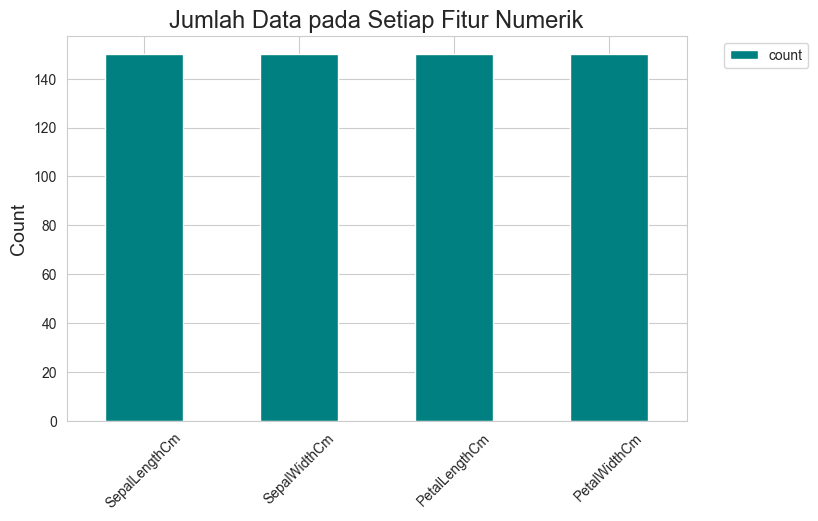

In [17]:
# Menghapus kolom Id (jika masih ada)
# Lakukan ini hanya jika kolom Id belum dihapus sebelumnya
if 'Id' in train.columns:
    train_numeric = train.drop('Id', axis=1)
else:
    train_numeric = train

# Membuat deskripsi statistik
d = train_numeric.describe()
dT = d.T

# Membuat Bar Plot untuk jumlah data (count)
dT.plot.bar(y='count', color='teal', figsize=(8,5))

plt.title("Jumlah Data pada Setiap Fitur Numerik", fontsize=17)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45) # Memiringkan nama fitur agar mudah dibaca
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Memindahkan legend agar tidak menutupi bar

In [18]:
# Hapus kolom 'Id' karena hanya berisi nomor urut dan tidak berpengaruh pada klasifikasi spesies
if 'Id' in train.columns:
    train.drop('Id', axis=1, inplace=True)

# Dataset Iris biasanya tidak memiliki null value, 
# tapi baris ini tetap bisa dijalankan untuk memastikan data benar-benar bersih
train.dropna(inplace=True)

# Menampilkan 5 data teratas setelah pembersihan
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
# Cek dulu apakah kolom 'Id' ada sebelum menghapusnya
if 'Id' in train.columns:
    train.drop(['Id'], axis=1, inplace=True)
    print("Kolom 'Id' berhasil dihapus.")
else:
    print("Kolom 'Id' sudah tidak ada atau sudah dihapus sebelumnya.")

# Tampilkan data
train.head()

Kolom 'Id' sudah tidak ada atau sudah dihapus sebelumnya.


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Melakukan encoding pada kolom 'Species'
train['Species'] = le.fit_transform(train['Species'])

# Menampilkan 5 data teratas untuk melihat perubahannya
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [21]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
# Kita menghapus kolom 'Species' dari X dan menjadikannya sebagai y
X = train.drop('Species', axis=1)
y = train['Species']

# Membagi data menjadi training set dan testing set (30% untuk testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [22]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 4)
Test shape: (45, 4)


# **KNN**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
y_pred = clf1.predict(X_test)

### Evaluation

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediksi (pastikan model sudah dilatih sebelumnya)
y_pred = model.predict(X_test)

# 1. Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model: {accuracy:.2f}')

# 2. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 3. Classification Report
print("\nClassification Report:")
try:
    target_names = le.inverse_transform([0, 1, 2])
    print(classification_report(y_test, y_pred, target_names=target_names))
except:
    print(classification_report(y_test, y_pred))

Akurasi Model: 1.00

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [29]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Inisialisasi dan Training Model KNN
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

# 2. Melakukan Prediksi
y_pred1 = clf2.predict(X_test)

# 3. Evaluasi Model
accuracy = accuracy_score(y_test, y_pred1)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred1))

# 4. Laporan Klasifikasi dengan Nama Spesies
# Jika Anda menggunakan LabelEncoder sebelumnya, kita bisa memunculkan nama aslinya
try:
    # Mengambil nama asli spesies dari LabelEncoder (le)
    target_names = le.classes_ 
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred1, target_names=target_names))
except NameError:
    # Jika LabelEncoder tidak ditemukan, gunakan default (angka)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Definisikan metrik-metrik scoring
# Gunakan zero_division=0 untuk menghindari warning jika ada kelas yang tidak terprediksi
scoring = {
    'accuracy':  'accuracy', # String 'accuracy' sudah cukup
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall':    make_scorer(recall_score, average='macro', zero_division=0),
    'f1':        make_scorer(f1_score, average='macro', zero_division=0)
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9], # Menambah opsi k ganjil agar tidak seri
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan refit='f1'
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Disederhanakan agar mudah dibaca)
cv_results = pd.DataFrame(grid_search.cv_results_)

# Mengambil kolom penting saja
columns_to_show = ['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']
cv_metrics = cv_results[columns_to_show]

print("\n=== Top 5 Parameter Terbaik Berdasarkan F1-Score ===")
# Menampilkan 5 teratas yang sudah diurutkan
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False).head(5))

# 6. Menampilkan parameter terbaik yang terpilih
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Top 5 Parameter Terbaik Berdasarkan F1-Score ===
                                              params  mean_test_accuracy  \
4  {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
5  {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
7  {'metric': 'euclidean', 'n_neighbors': 9, 'wei...            0.952381   
1  {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2  {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   

   mean_test_precision  mean_test_recall  mean_test_f1  
4             0.962593          0.953571      0.953970  
5             0.962593          0.953571      0.953970  
7             0.962593          0.953571      0.953970  
1             0.956111          0.945238      0.945002  
2             0.956111          0.945238      0.945002  

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best

In [32]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [33]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [34]:
# 1. Ambil model terbaik dari hasil GridSearch sebelumnya
best_model = grid_search.best_estimator_

# 2. Lakukan prediksi pada data Test
y_pred = best_model.predict(X_test)

# 3. Hitung metrik evaluasi
print("\n=== Evaluasi di Test Set (Model Terbaik) ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

# 4. Classification Report dengan nama spesies asli
print("\nClassification Report:")
try:
    # Menggunakan le.classes_ jika Anda menggunakan LabelEncoder sebelumnya
    print(classification_report(y_test, y_pred, target_names=le.classes_))
except:
    print(classification_report(y_test, y_pred))

# 5. Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set (Model Terbaik) ===
Akurasi:  1.0000
Presisi:  1.0000
Recall:   1.0000
F1-Score: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [35]:
import pandas as pd

# Masukkan data baru sebagai DataFrame dengan nama kolom yang sesuai
new_data_df = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], 
                           columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

# Prediksi menggunakan DataFrame
prediction = best_model.predict(new_data_df)

# Mengubah label angka kembali menjadi nama spesies asli
spesies = le.inverse_transform(prediction)

print(f"Hasil Prediksi: {prediction[0]} ({spesies[0]})")

Hasil Prediksi: 0 (Iris-setosa)
